# 严格 Holdout +6dB 主目标实现与可视化报告

本 Notebook 用于复现实验实现流程，并给出可视化结果。

当前主目标口径：
- 在 strict holdout 下（test split + warmstart level=3 + early_window_s=0.25s），
- 主验收指标为 `early_gain_db_mean >= 6.0 dB`（相对 Zero-init），
- `sample_6db_pass_rate` 作为稳定性监控项。

Notebook 结构：
1. 数据集加载与房间可视化（可选房间、降噪效果、W_full 初始化 vs 零初始化 vs AI 初始化）
2. 网络与训练（实时可视化 train/valid loss，并跟踪其作为 w_init 的 early gain 趋势）
3. 测试与统计（房间级曲线对比 + 全测试集统计）

说明：
- 本 Notebook 严格使用 train/val/test 切分。
- AI 初始化默认使用你训练得到的 checkpoint；如未提供，会自动跳过 AI 曲线。

In [1]:
# 环境与依赖
# 如果缺少依赖，请取消下一行注释执行
# %pip install numpy pandas matplotlib h5py torch

from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.utils.data import DataLoader

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("h5py:", h5py.__version__)

numpy: 1.26.4
torch: 2.4.0
h5py: 3.16.0


In [2]:
# 项目路径与模块导入
ROOT = Path.cwd().resolve()
if not (ROOT / "python_impl").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "python_impl").exists():
            ROOT = parent
            break
PY_IMPL = ROOT / "python_impl"
if str(PY_IMPL) not in sys.path:
    sys.path.insert(0, str(PY_IMPL))

from py_anc.algorithms import cfxlms
from py_anc.scenarios import plot_layout_with_labels
from py_anc.utils import wn_gen
from python_scripts.cfxlms_single_control_dataset_impl import (
    AcousticScenarioSampler,
    DatasetBuildConfig,
    _cfxlms_with_init,
    _normalize_columns,
    _rolling_mse_db,
)
from python_scripts.evaluate_hybrid_deep_fxlms_single_control import (
    load_target_metric_values,
    warmstart_metrics,
)
from python_scripts.train_hybrid_deep_fxlms_single_control import (
    HybridAncDataset,
    HybridDeepFxLMSNet,
    level_mask,
    load_bundle,
    run_epoch,
    split_indices_train_val_test,
)

print("ROOT:", ROOT)

ROOT: Z:\anc\distributed_anc_sim_py


In [3]:
# 全局配置
H5_PATH = ROOT / "python_impl" / "python_scripts" / "cfxlms_qc_dataset_single_control.h5"
DEVICE = torch.device("cpu")

SPLIT_SEED = 7
VAL_FRAC = 0.2
TEST_FRAC = 0.2
WARMSTART_LEVEL = 3
WARMSTART_CASES = 8
EARLY_WINDOW_S = 0.25
MIN_IMPROVEMENT_DB = 6.0
MONITOR_SAMPLE_6DB_TARGET = 0.9
HALF_TARGET_RATIO = 0.5  # legacy reference

# 可选：填入已有 checkpoint（例如 strict_goal_route_none_b10_v1 的某个seed）
AI_CHECKPOINT_PATH = ROOT / "python_impl" / "experiments" / "anc_single_control" / "strict_goal_route_none_b10_v1_20260404" / "b10_ri_cross_freq_lam1e3_b64" / "seed_7" / "train" / "final_hybrid_deep_fxlms.pt"

# 房间选择（来自 test split）
SELECT_ROOM_RANK_IN_TEST = 0

print("H5 exists:", H5_PATH.exists())
print("AI checkpoint exists:", AI_CHECKPOINT_PATH.exists())
print("目标: early_gain_db_mean >=", MIN_IMPROVEMENT_DB, "dB")
print("监控: sample_6db_pass_rate 目标 =", MONITOR_SAMPLE_6DB_TARGET)

H5 exists: True
AI checkpoint exists: True
目标: early_gain_db_mean >= 6.0 dB
监控: sample_6db_pass_rate 目标 = 0.9


## 第一部分：数据集加载、可选房间与可视化

本部分完成：
- 加载数据集与 strict split
- 从 test split 选择房间
- 可视化房间布局
- 对比 `Zero-init FxLMS`、`W_full-init FxLMS`、`AI-init FxLMS`（若 checkpoint 可用）

In [4]:
# 数据加载与strict split
with h5py.File(str(H5_PATH), "r") as h5:
    cfg = DatasetBuildConfig(**json.loads(h5.attrs["config_json"]))
    image_order = np.asarray(h5["raw/room_params/image_source_order"], dtype=np.int64)
    w_full_all = np.asarray(h5["raw/W_full"], dtype=np.float32)

all_idx = np.arange(image_order.shape[0], dtype=np.int64)
train_idx, val_idx, test_idx = split_indices_train_val_test(
    indices=all_idx,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SPLIT_SEED,
)

lvl_mask = np.where(level_mask(image_order, WARMSTART_LEVEL))[0].astype(np.int64)
test_level_idx = np.intersect1d(test_idx, lvl_mask)

if test_level_idx.size == 0:
    raise RuntimeError("test split in selected level is empty")

room_idx = int(test_level_idx[min(SELECT_ROOM_RANK_IN_TEST, test_level_idx.size - 1)])

print({
    "n_rooms": int(image_order.shape[0]),
    "n_train": int(train_idx.size),
    "n_val": int(val_idx.size),
    "n_test": int(test_idx.size),
    "n_test_level": int(test_level_idx.size),
    "selected_room_idx": room_idx,
})

{'n_rooms': 2000, 'n_train': 1280, 'n_val': 320, 'n_test': 400, 'n_test_level': 351, 'selected_room_idx': 7}


In [5]:
# 第一部分工具函数：房间重建、AI预测、曲线绘制

def build_manager_from_h5_room(h5_path: Path, idx: int):
    with h5py.File(str(h5_path), "r") as h5:
        cfg_local = DatasetBuildConfig(**json.loads(h5.attrs["config_json"]))
        room = h5["raw/room_params"]
        sampled = {
            "room_size": np.asarray(room["room_size"][idx], dtype=float),
            "source_pos": np.asarray(room["source_position"][idx], dtype=float),
            "ref_positions": np.asarray(room["ref_positions"][idx], dtype=float),
            "sec_positions": np.asarray(room["sec_positions"][idx], dtype=float),
            "err_positions": np.asarray(room["err_positions"][idx], dtype=float),
            "ref_azimuth_deg": np.asarray(room["ref_azimuth_deg"][idx], dtype=float),
            "ref_radii": np.asarray(room["ref_radii"][idx], dtype=float),
            "sec_source_distance": float(room["sec_source_distance"][idx]),
            "err_source_distance": float(room["err_source_distance"][idx]),
            "sec_err_distance": float(room["sec_err_distance"][idx]),
            "primary_advance_margin_min": float(room["primary_advance_margin_min"][idx]),
            "secondary_feedback_margin_min": float(room["secondary_feedback_margin_min"][idx]),
            "sound_speed": float(room["sound_speed"][idx]),
            "absorption": float(room["material_absorption"][idx]),
            "image_order": int(room["image_source_order"][idx]),
            "layout_mode": str(room["layout_mode"][idx]),
        }
        source_seed = int(h5["raw/qc_metrics/source_seed"][idx])
        mu_used = float(h5["raw/qc_metrics/mu_used"][idx])

    sampler = AcousticScenarioSampler(cfg_local, np.random.default_rng(int(cfg_local.random_seed)))
    mgr = sampler.build_manager(sampled)
    mgr.build(verbose=False)

    noise, t = wn_gen(
        fs=int(cfg_local.fs),
        duration=float(cfg_local.noise_duration_s),
        f_low=float(cfg_local.f_low),
        f_high=float(cfg_local.f_high),
        rng=np.random.default_rng(source_seed),
    )
    source_signal = _normalize_columns(noise)
    time_axis = np.asarray(t[:, 0], dtype=float)
    x = _normalize_columns(mgr.calculate_reference_signal(source_signal, len(time_axis)))
    d = mgr.calculate_desired_signal(source_signal, len(time_axis))

    return cfg_local, mgr, time_axis, x, d, mu_used, sampler


def run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init, mu_used):
    if w_init is None:
        out = cfxlms({
            "time": t,
            "rir_manager": mgr,
            "L": int(cfg_local.filter_len),
            "mu": float(mu_used),
            "reference_signal": x,
            "desired_signal": d,
            "verbose": False,
            "normalized_update": bool(cfg_local.anc_normalized_update),
            "norm_epsilon": float(cfg_local.anc_norm_epsilon),
        })
        return np.asarray(out["err_hist"], dtype=float)

    out = _cfxlms_with_init(
        t,
        mgr,
        int(cfg_local.filter_len),
        float(mu_used),
        x,
        d,
        w_init=w_init,
        normalized_update=bool(cfg_local.anc_normalized_update),
        norm_epsilon=float(cfg_local.anc_norm_epsilon),
    )
    return np.asarray(out["err_hist"], dtype=float)


def load_ai_model_and_predict(checkpoint_path: Path, h5_path: Path, room_indices: np.ndarray):
    if not checkpoint_path.exists():
        return None

    ckpt = torch.load(str(checkpoint_path), map_location="cpu", weights_only=False)
    train_args = ckpt["args"]
    bundle = load_bundle(h5_path=h5_path, encoding=str(train_args["feature_encoding"]), disable_feature_b=bool(train_args["disable_feature_b"]))

    acoustic_in = 1 if bundle.acoustic is None else int(bundle.acoustic.shape[1])
    model = HybridDeepFxLMSNet(
        acoustic_in_channels=acoustic_in,
        filter_len=int(bundle.p_ref.shape[-1]),
        num_refs=int(bundle.p_ref.shape[1]),
        basis_dim=int(train_args["basis_dim"]),
        embed_dim=int(train_args["embed_dim"]),
        fusion_mode=str(train_args["fusion_mode"]),
        num_heads=int(train_args["num_heads"]),
        disable_feature_b=bool(train_args["disable_feature_b"]),
        use_path_features=bool(train_args.get("use_path_features", False)),
        use_index_embedding=bool(train_args.get("use_index_embedding", False)),
        index_direct_lookup=bool(train_args.get("index_direct_lookup", False)),
        num_samples=int(bundle.gcc.shape[0]),
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    ds = HybridAncDataset(bundle=bundle, indices=np.asarray(room_indices, dtype=np.int64))
    dl = DataLoader(ds, batch_size=min(32, len(ds)), shuffle=False)

    preds = []
    with torch.no_grad():
        for gcc, acoustic, p_ref, d_path, s_path, _, _, _, sample_idx in dl:
            out = model(
                gcc=gcc.to(DEVICE, dtype=torch.float32),
                acoustic=acoustic.to(DEVICE, dtype=torch.float32),
                p_ref=p_ref.to(DEVICE, dtype=torch.float32),
                d_path=d_path.to(DEVICE, dtype=torch.float32),
                s_path=s_path.to(DEVICE, dtype=torch.float32),
                sample_idx=sample_idx.to(DEVICE, dtype=torch.long),
            )
            preds.append(out["w_pred"].cpu().numpy())
    return np.concatenate(preds, axis=0)


def plot_room_curves(t, d, e_zero, e_wfull, e_ai=None):
    plt.figure(figsize=(10, 4))
    mic = 0
    t0, nr_zero = _rolling_mse_db(e_zero[:, mic], fs=int(cfg.fs), window_samples=max(64, int(cfg.fs * 0.25)))
    _, nr_wfull = _rolling_mse_db(e_wfull[:, mic], fs=int(cfg.fs), window_samples=max(64, int(cfg.fs * 0.25)))
    plt.plot(t0, nr_zero, label="Zero-init", linestyle="--")
    plt.plot(t0, nr_wfull, label="W_full-init", linewidth=2)
    if e_ai is not None:
        _, nr_ai = _rolling_mse_db(e_ai[:, mic], fs=int(cfg.fs), window_samples=max(64, int(cfg.fs * 0.25)))
        plt.plot(t0, nr_ai, label="AI-init", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Error Power (dB)")
    plt.title("Room-level NR Curve (Err Mic 0)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

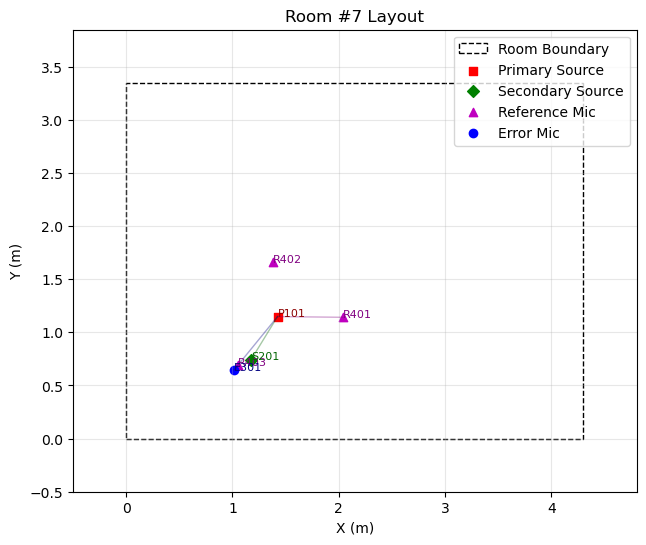

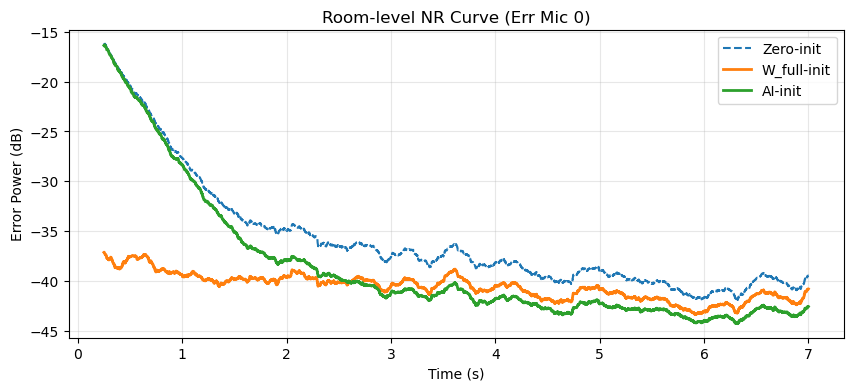

Init NR (dB):
  Zero-init: 2.062
  W_full-init: 22.932
  AI-init: 2.178


In [7]:
# 选择房间并可视化布局 + 三种初始化对比
cfg_local, mgr, t, x, d, mu_used, sampler = build_manager_from_h5_room(H5_PATH, room_idx)

# 布局图
_ = plot_layout_with_labels(
    mgr,
    source_ids=np.asarray(sampler.source_id, dtype=int).reshape(-1),
    ref_ids=sampler.ref_ids,
    sec_ids=sampler.sec_ids,
    err_ids=sampler.err_ids,
    title=f"Room #{room_idx} Layout",
)
plt.show()

# Zero-init
e_zero = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=None, mu_used=mu_used)

# W_full-init
w_full_room = w_full_all[room_idx]
e_wfull = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_full_room, mu_used=mu_used)

# AI-init（可选）
e_ai = None
if AI_CHECKPOINT_PATH.exists():
    ai_pred = load_ai_model_and_predict(AI_CHECKPOINT_PATH, H5_PATH, np.asarray([room_idx], dtype=np.int64))
    e_ai = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=ai_pred[0][None, :, :], mu_used=mu_used)

plot_room_curves(t, d, e_zero, e_wfull, e_ai=e_ai)

# 简单指标

def init_nr_db(d_sig, e_sig, fs, early_s=0.25):
    n = min(len(d_sig), len(e_sig))
    m = min(n, max(8, int(fs * early_s)))
    d_pow = float(np.mean(d_sig[:m, 0] ** 2)) + 1e-12
    e_pow = float(np.mean(e_sig[:m, 0] ** 2)) + 1e-12
    return 10.0 * np.log10(d_pow / e_pow)

print("Init NR (dB):")
print("  Zero-init:", round(init_nr_db(d, e_zero, cfg_local.fs), 3))
print("  W_full-init:", round(init_nr_db(d, e_wfull, cfg_local.fs), 3))
if e_ai is not None:
    print("  AI-init:", round(init_nr_db(d, e_ai, cfg_local.fs), 3))

## 第二部分：网络与训练（实时可视化）

本部分提供一个最小可行训练循环：
- 每轮显示 `train_loss` / `val_loss`
- 定期在固定验证探针房间上计算 AI 作为 `w_init` 的初始降噪量

In [6]:
# 构建训练对象
bundle = load_bundle(H5_PATH, encoding="ri", disable_feature_b=False)
all_indices = np.arange(bundle.gcc.shape[0], dtype=np.int64)
train_idx, val_idx, test_idx = split_indices_train_val_test(all_indices, VAL_FRAC, TEST_FRAC, SPLIT_SEED)

train_ds = HybridAncDataset(bundle=bundle, indices=train_idx)
val_ds = HybridAncDataset(bundle=bundle, indices=val_idx)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

model = HybridDeepFxLMSNet(
    acoustic_in_channels=int(bundle.acoustic.shape[1]),
    filter_len=int(bundle.p_ref.shape[-1]),
    num_refs=int(bundle.p_ref.shape[1]),
    basis_dim=64,
    embed_dim=128,
    fusion_mode="cross",
    num_heads=4,
    disable_feature_b=False,
    use_path_features=True,
    use_index_embedding=False,
    index_direct_lookup=False,
    num_samples=int(bundle.gcc.shape[0]),
).to(DEVICE)

from py_anc.algorithms.hybrid_loss import HybridAcousticLoss
loss_module = HybridAcousticLoss(
    lambda_reg=1e-3,
    conv_domain="freq",
    nr_margin_weight=0.0,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 固定探针（验证集前若干个房间）
val_probe_idx = val_idx[: min(8, len(val_idx))]
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx), "probe:", len(val_probe_idx))

train/val/test: 1280 320 400 probe: 8


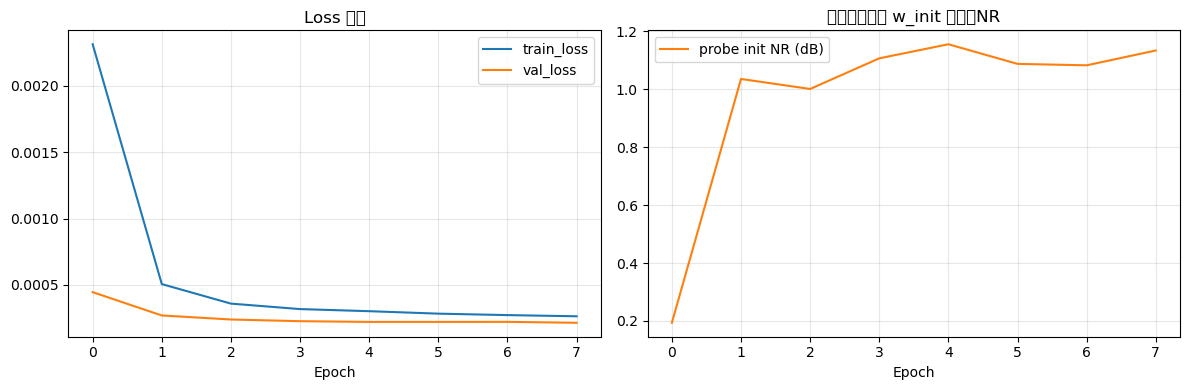

训练完成


In [ ]:
# 训练循环（实时可视化 loss 与 warmstart early gain）

def predict_w_for_indices(model_obj, bundle_obj, idx_array):
    ds = HybridAncDataset(bundle=bundle_obj, indices=np.asarray(idx_array, dtype=np.int64))
    dl = DataLoader(ds, batch_size=min(32, len(ds)), shuffle=False)
    out = []
    model_obj.eval()
    with torch.no_grad():
        for gcc, acoustic, p_ref, d_path, s_path, _, _, _, sample_idx in dl:
            pred = model_obj(
                gcc=gcc.to(DEVICE, dtype=torch.float32),
                acoustic=acoustic.to(DEVICE, dtype=torch.float32),
                p_ref=p_ref.to(DEVICE, dtype=torch.float32),
                d_path=d_path.to(DEVICE, dtype=torch.float32),
                s_path=s_path.to(DEVICE, dtype=torch.float32),
                sample_idx=sample_idx.to(DEVICE, dtype=torch.long),
            )["w_pred"].cpu().numpy()
            out.append(pred)
    return np.concatenate(out, axis=0)

train_losses, val_losses, probe_early_gain = [], [], []
EPOCHS = 8

for ep in range(1, EPOCHS + 1):
    train_m = run_epoch(
        loader=train_loader,
        model=model,
        device=DEVICE,
        loss_module=loss_module,
        optimizer=optimizer,
        margin_weight=0.0,
        supervision_weight=0.0,
        supervision_source="none",
        acoustic_loss_weight=1.0,
        grad_clip_norm=5.0,
    )
    val_m = run_epoch(
        loader=val_loader,
        model=model,
        device=DEVICE,
        loss_module=loss_module,
        optimizer=None,
        margin_weight=0.0,
        supervision_weight=0.0,
        supervision_source="none",
        acoustic_loss_weight=1.0,
        grad_clip_norm=5.0,
    )

    train_losses.append(float(train_m["loss_total"]))
    val_losses.append(float(val_m["loss_total"]))

    w_probe = predict_w_for_indices(model, bundle, val_probe_idx)
    probe_targets = load_target_metric_values(H5_PATH, [int(v) for v in val_probe_idx.tolist()], "nr_last_db")
    probe_warm = warmstart_metrics(
        h5_path=H5_PATH,
        room_indices=[int(v) for v in val_probe_idx.tolist()],
        w_pred=w_probe,
        early_window_s=EARLY_WINDOW_S,
        target_nr_db=probe_targets,
        half_target_ratio=HALF_TARGET_RATIO,
        target_metric="nr_last_db",
        min_improvement_db=MIN_IMPROVEMENT_DB,
    )
    probe_early_gain.append(float(probe_warm["early_gain_db_mean"]))

    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(train_losses, label="train_loss")
    ax[0].plot(val_losses, label="val_loss")
    ax[0].set_title("Loss 曲线")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(probe_early_gain, label="probe early_gain_db_mean", color="tab:orange")
    ax[1].axhline(MIN_IMPROVEMENT_DB, color="k", linestyle="--", linewidth=1, label="target")
    ax[1].set_title("验证探针作为 w_init 的 early gain (dB)")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    display(fig)
    plt.close(fig)

print("训练完成")

## 第三部分：测试集对比与全局统计

本部分完成：
- 指定 test 房间列表，比较 `AI-init`、`W_full-init`、`Zero-init` 曲线
- 在更大 test 子集上汇总统计（`improvement_gap_db`、`early_gain_db_mean`、`sample_6db_pass_rate`），并保留 legacy half-target 侧观察

Room 7:


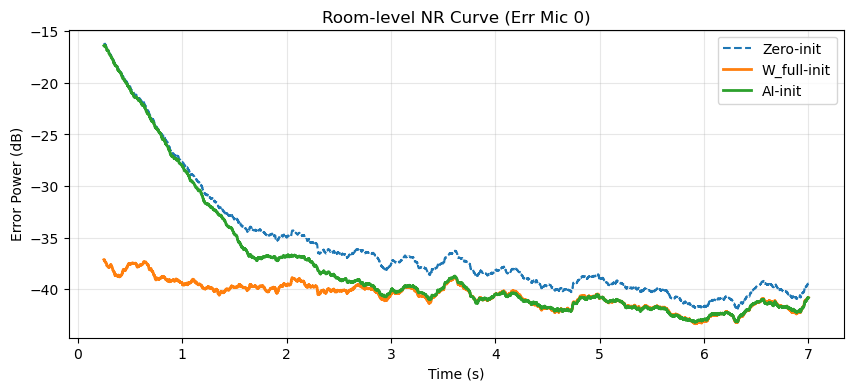

Room 8:


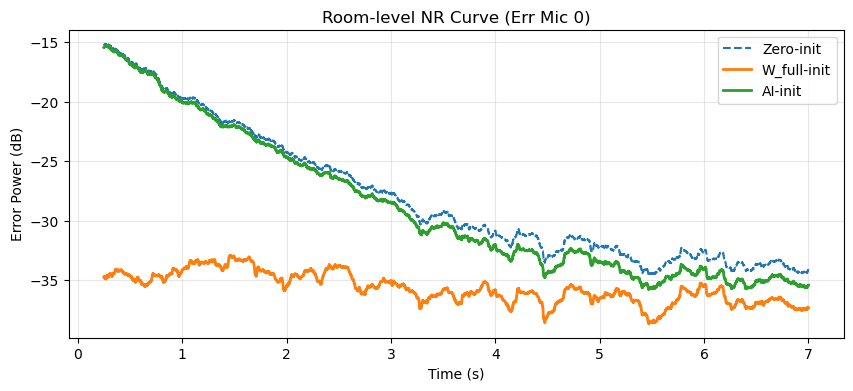

Room 15:


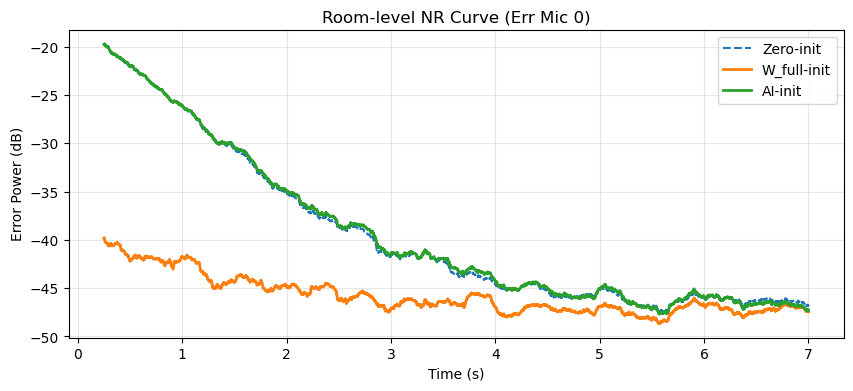

In [10]:
# 房间级对比：AI-init vs W_full-init vs Zero-init
show_rooms = test_level_idx[: min(3, len(test_level_idx))]

# AI 权重来源：优先使用本 notebook 训练后的 model
w_ai_rooms = predict_w_for_indices(model, bundle, show_rooms)

for ridx, w_ai in zip(show_rooms.tolist(), w_ai_rooms):
    cfg_local, mgr, t, x, d, mu_used, sampler = build_manager_from_h5_room(H5_PATH, int(ridx))
    e_zero = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=None, mu_used=mu_used)
    e_wfull = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_full_all[int(ridx)], mu_used=mu_used)
    e_ai = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_ai[None, :, :], mu_used=mu_used)

    print(f"Room {ridx}:")
    plot_room_curves(t, d, e_zero, e_wfull, e_ai=e_ai)

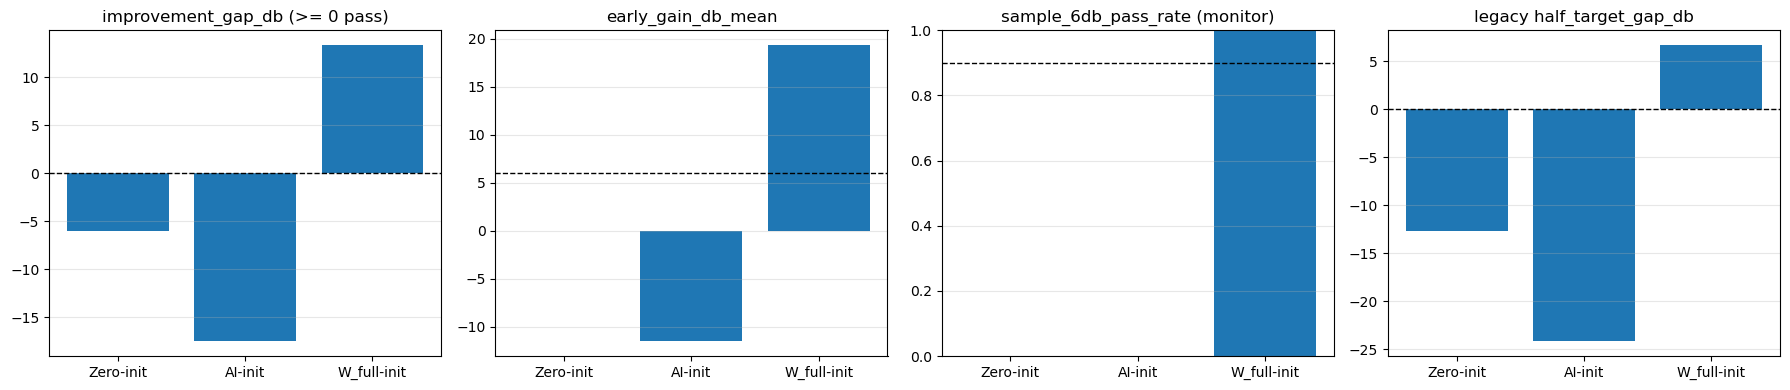

目标阈值 MIN_IMPROVEMENT_DB = 6.0
监控阈值 MONITOR_SAMPLE_6DB_TARGET = 0.9
AI: {'early_gain_db_mean': -11.530105749470462, 'convergence_step_ratio_mean': 0.97793694884665, 'min_improvement_db': 6.0, 'improvement_gap_db': -17.53010574947046, 'improvement_pass': False, 'sample_improvement_pass_rate': 0.0, 'sample_6db_pass_rate': 0.0, 'init_nr_db_mean': -10.051731536951873, 'target_metric': 'nr_last_db', 'target_nr_db_mean': 28.25067761540413, 'half_target_ratio': 0.5, 'half_target_threshold_db': 14.125338807702065, 'half_target_gap_db': -24.177070344653938, 'half_target_pass': False, 'sample_pass_rate': 0.0, 'num_samples': 64}
W_full: {'early_gain_db_mean': 19.344501719356913, 'convergence_step_ratio_mean': 2.400125734233964, 'min_improvement_db': 6.0, 'improvement_gap_db': 13.344501719356913, 'improvement_pass': True, 'sample_improvement_pass_rate': 1.0, 'sample_6db_pass_rate': 1.0, 'init_nr_db_mean': 20.822333840679953, 'target_metric': 'nr_last_db', 'target_nr_db_mean': 28.25067761540413, 'ha

In [8]:
# 全测试子集统计对比（主目标：相对 zero-init 的 early_gain_db_mean >= MIN_IMPROVEMENT_DB）
if "predict_w_for_indices" not in globals():
    def predict_w_for_indices(model_obj, bundle_obj, idx_array):
        ds = HybridAncDataset(bundle=bundle_obj, indices=np.asarray(idx_array, dtype=np.int64))
        dl = DataLoader(ds, batch_size=min(32, len(ds)), shuffle=False)
        out = []
        model_obj.eval()
        with torch.no_grad():
            for gcc, acoustic, p_ref, d_path, s_path, _, _, _, sample_idx in dl:
                pred = model_obj(
                    gcc=gcc.to(DEVICE, dtype=torch.float32),
                    acoustic=acoustic.to(DEVICE, dtype=torch.float32),
                    p_ref=p_ref.to(DEVICE, dtype=torch.float32),
                    d_path=d_path.to(DEVICE, dtype=torch.float32),
                    s_path=s_path.to(DEVICE, dtype=torch.float32),
                    sample_idx=sample_idx.to(DEVICE, dtype=torch.long),
                )["w_pred"].cpu().numpy()
                out.append(pred)
        return np.concatenate(out, axis=0)

agg_count = min(64, len(test_level_idx))
agg_idx = test_level_idx[:agg_count]
agg_list = [int(v) for v in agg_idx.tolist()]

# AI / W_full / Zero 三种 w_init
w_ai = predict_w_for_indices(model, bundle, agg_idx)
w_wfull = w_full_all[agg_idx, 0, :, :]
w_zero = np.zeros_like(w_wfull)

target_vals = load_target_metric_values(H5_PATH, agg_list, "nr_last_db")

m_ai = warmstart_metrics(
    H5_PATH,
    agg_list,
    w_ai,
    EARLY_WINDOW_S,
    target_vals,
    HALF_TARGET_RATIO,
    "nr_last_db",
    min_improvement_db=MIN_IMPROVEMENT_DB,
)
m_wf = warmstart_metrics(
    H5_PATH,
    agg_list,
    w_wfull,
    EARLY_WINDOW_S,
    target_vals,
    HALF_TARGET_RATIO,
    "nr_last_db",
    min_improvement_db=MIN_IMPROVEMENT_DB,
)
m_ze = warmstart_metrics(
    H5_PATH,
    agg_list,
    w_zero,
    EARLY_WINDOW_S,
    target_vals,
    HALF_TARGET_RATIO,
    "nr_last_db",
    min_improvement_db=MIN_IMPROVEMENT_DB,
)

labels = ["Zero-init", "AI-init", "W_full-init"]
improvement_gaps = [m_ze["improvement_gap_db"], m_ai["improvement_gap_db"], m_wf["improvement_gap_db"]]
early_gains = [m_ze["early_gain_db_mean"], m_ai["early_gain_db_mean"], m_wf["early_gain_db_mean"]]
sample_6db_rates = [m_ze["sample_6db_pass_rate"], m_ai["sample_6db_pass_rate"], m_wf["sample_6db_pass_rate"]]
legacy_half_gaps = [m_ze["half_target_gap_db"], m_ai["half_target_gap_db"], m_wf["half_target_gap_db"]]

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].bar(labels, improvement_gaps)
ax[0].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[0].set_title("improvement_gap_db (>= 0 pass)")
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(labels, early_gains)
ax[1].axhline(MIN_IMPROVEMENT_DB, color="k", linestyle="--", linewidth=1)
ax[1].set_title("early_gain_db_mean")
ax[1].grid(axis="y", alpha=0.3)

ax[2].bar(labels, sample_6db_rates)
ax[2].axhline(MONITOR_SAMPLE_6DB_TARGET, color="k", linestyle="--", linewidth=1)
ax[2].set_ylim(0, 1)
ax[2].set_title("sample_6db_pass_rate (monitor)")
ax[2].grid(axis="y", alpha=0.3)

ax[3].bar(labels, legacy_half_gaps)
ax[3].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[3].set_title("legacy half_target_gap_db")
ax[3].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("目标阈值 MIN_IMPROVEMENT_DB =", MIN_IMPROVEMENT_DB)
print("监控阈值 MONITOR_SAMPLE_6DB_TARGET =", MONITOR_SAMPLE_6DB_TARGET)
print("AI:", m_ai)
print("W_full:", m_wf)
print("Zero:", m_ze)